In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits
import healpy as hp
import yaml

from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
nmad = lambda x: 1.4826 * np.median(np.abs(x-np.median(x)))

In [4]:
min_nobs = 2
max_ebv = 0.15
max_stardens = 2500

In [5]:
tiles = Table(fitsio.read('/global/cfs/cdirs/desi/spectro/redux/himalayas/tiles-himalayas.fits'))
mask = tiles['SURVEY']=='sv1'
mask &= (tiles['FAPRGRM']=='lrgqso') | (tiles['FAPRGRM']=='lrgqso2')
mask &= tiles['LRG_EFFTIME_DARK']>2000.
tiles = tiles[mask]
print(len(tiles))

38


In [6]:
tmp = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/dr9_extended_lrg_0.49.0_pzbins_20230120.fits'))
tmp1 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/more/dr9_extended_lrg_0.49.0_pzbins_20230120-weights.fits'))
lrg = hstack([tmp, tmp1], join_type='exact')
print(len(lrg))

mask = lrg['extended_lrg'].copy()
lrg = lrg[mask]
print(len(lrg))

35354635
33789294


In [7]:
target_bit = 6  # LRG_SV_IR
fn = '/global/cfs/cdirs/desi/spectro/redux/himalayas/zcatalog/ztile-sv1-dark-cumulative.fits'
cat = Table(fitsio.read(fn, columns=['SV1_DESI_TARGET']))
idx = np.where(cat['SV1_DESI_TARGET'] & 2**target_bit > 0)[0]
cat = Table(fitsio.read(fn, rows=idx))
print(len(cat), len(np.unique(cat['TARGETID'])))

# Select QSO+LRG tiles
mask = np.in1d(cat['TILEID'], tiles['TILEID'])
cat = cat[mask]
print(len(cat), len(np.unique(cat['TARGETID'])))

# Select objects in the extended sample
mask = np.in1d(cat['TARGETID'], lrg['TARGETID'])
cat = cat[mask]
print(len(cat), len(np.unique(cat['TARGETID'])))

cat.rename_columns(['TARGET_RA', 'TARGET_DEC'], ['RA', 'DEC'])

cat = join(cat, lrg[['TARGETID', 'PIXEL_NOBS_G', 'PIXEL_NOBS_R', 'PIXEL_NOBS_Z', 'pz_bin', 'weight', 'lrg_mask']], keys='TARGETID')
cat.rename_column('weight', 'imaging_weight')
print(len(cat))

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 2000.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove duplicated objects
print(len(cat), len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])))

bad_fibers = np.loadtxt('/global/u2/r/rongpu/notebooks/lrg_xcorr/data/bad_fibers_himalayas_20230106.txt', dtype=int)
print(len(bad_fibers))
# bad fibers identified from redshift distributions (https://github.com/desihub/desispec/issues/1946)
additional_bad_fibers = [466, 1008, 1098, 1219, 1251, 2675, 2676, 2677, 2678, 2679, 2680, 3994, 3995, 4349, 4720, 2250, 2251, 2252, 2253, 3038]
bad_fibers = np.unique(np.concatenate([bad_fibers, additional_bad_fibers]))
print(len(bad_fibers))
print(bad_fibers)
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

mask = (cat['PIXEL_NOBS_G']>=min_nobs) & (cat['PIXEL_NOBS_R']>=min_nobs) & (cat['PIXEL_NOBS_Z']>=min_nobs)
print('NOBS', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# Martin's EBV cut
mask = cat['EBV']<max_ebv
print('EBV', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Martin's STARDENS cut
stardens = np.load('/global/cfs/cdirs/desi/users/rongpu/useful/healpix_maps/pixweight-dr7.1-0.22.0_stardens_64_ring.npy')
stardens_nside = 64
mask = stardens>=max_stardens
bad_hp_idx = np.arange(len(stardens))[mask]
cat_hp_idx = hp.pixelfunc.ang2pix(stardens_nside, cat['RA'], cat['DEC'], lonlat=True, nest=False)
mask_bad = np.in1d(cat_hp_idx, bad_hp_idx)
print('STARDENS', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

# # Remove objects classified as STARs
# mask = (cat['SPECTYPE']!='STAR') & (cat['Z']>=0.0003)
# print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat = cat[mask]

# # exclude QSO targets
# mask = ~((cat["SV1_DESI_TARGET"] & (2**2))!=0)
# print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat = cat[mask]
# print(len(cat))

47954 47695
42069 41968
38907 38812
38907
FIBERSTATUS    6141 32766 0.15783792119669982
No data    0 32766 0.0
LRG mask 29767 2999 0.09152780321064519
Min depth    976 28791 0.032787986696677526
28791 28734
28734 28734
57
66
[ 466  552  651  817 1008 1098 1219 1251 1400 1597 1765 1969 2250 2251
 2252 2253 2259 2260 2261 2267 2271 2316 2575 2628 2636 2654 2663 2675
 2676 2677 2678 2679 2680 2681 2684 2685 2686 2687 2688 2689 3033 3038
 3082 3476 3500 3546 3618 3754 3849 3974 3994 3995 4002 4019 4089 4349
 4507 4613 4621 4624 4720 4733 4748 4788 4957 4977]
Bad fibers 28319 415 0.014442820352196005
NOBS 27408 911 0.9678307849853456
EBV 26760 648 0.023642732049036778
STARDENS 26071 689 0.025747384155455903


In [8]:
# Redshift quality cut
cat['q'] = cat['ZWARN']==0
cat['q'] &= cat['Z']<1.45
cat['q'] &= cat['DELTACHI2']>15
print(np.sum(~cat['q'])/len(cat))
mask_quality = cat['q'].copy()

print('Quality', np.sum(mask_quality), np.sum(~mask_quality), np.sum(~mask_quality)/len(mask_quality))
cat = cat[mask_quality]

0.010931686548272026
Quality 25786 285 0.010931686548272026


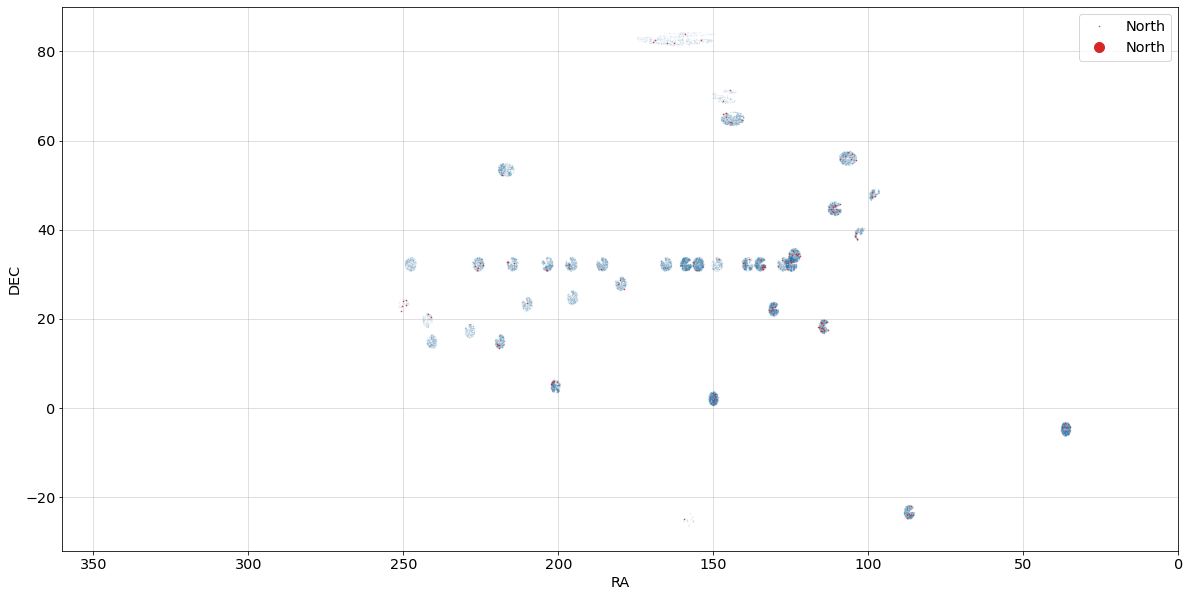

In [9]:
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)

plt.figure(figsize=(20, 10))
plt.plot(cat['RA'][~mask_star], cat['DEC'][~mask_star], 'C0.', ms=.05, label='North')
plt.plot(cat['RA'][mask_star], cat['DEC'][mask_star], 'C3.', ms=1, label='North')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.xlim(360, 0)
plt.show()

10954 14832


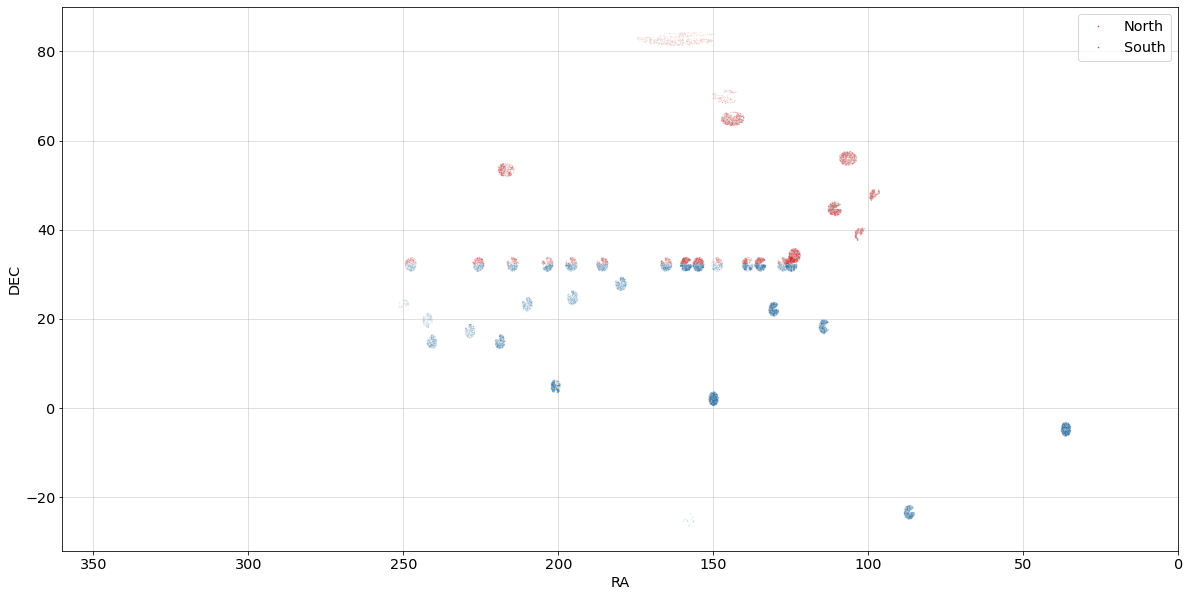

In [10]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

plt.figure(figsize=(20, 10))
plt.plot(cat['RA'][mask_north], cat['DEC'][mask_north], 'C3.', ms=.05, label='North')
plt.plot(cat['RA'][mask_south], cat['DEC'][mask_south], 'C0.', ms=.05, label='South')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.xlim(360, 0)
plt.show()

In [11]:
# numbers from extended_sample_target_densities_and_qso_target_fractions.ipynb

densities = {'all_south': 1673.960216419727,
             'all_north': 1695.4303242947576,
             'bin_1_south': 185.44617617247312,
             'bin_1_north': 186.28787764421088,
             'bin_2_south': 312.23760257188997,
             'bin_2_north': 309.0046515001803,
             'bin_3_south': 417.2338242804252,
             'bin_3_north': 435.8116996466394,
             'bin_4_south': 433.7446191493568,
             'bin_4_north': 456.0017321950825}

qso_fractions = {'S1': 0.005649310376720938,
                 'S2': 0.00893313310425617,
                 'S3': 0.011628792617132804,
                 'S4': 0.008378501777544664,
                 'N1': 0.005768231024851685,
                 'N2': 0.007706950005069857,
                 'N3': 0.008879980828304395,
                 'N4': 0.008569573978228088}

In [12]:
area_south = np.sum(mask_south)/densities['all_south']
print(area_south)

area_north = np.sum(mask_north)/densities['all_north']
print(area_north)

8.860425626914086
6.460896589517176


--------
# Weights

In [13]:
cat['spec_weight'] = 1.

mask_qso = cat['SV1_DESI_TARGET'] & 2**2>0
print(np.sum(mask_qso), np.sum(mask_qso)/len(mask_qso))

# QSO weights
for photsys in ['S', 'N']:
    for bin_index in range(1, 5):
        mask0 = cat['PHOTSYS']==photsys
        mask0 &= cat['pz_bin']==bin_index
        mask = mask0 & mask_qso
        qso_weight = qso_fractions[photsys+str(bin_index)] / (np.sum(mask)/np.sum(mask0))
        print(bin_index, np.sum(mask)/np.sum(mask0), qso_weight)
        cat['spec_weight'][mask] *= qso_weight

1040 0.04033196308074149
1 0.028151774785801713 0.2006733294687394
2 0.03576864535768645 0.24974759359558743
3 0.05580357142857143 0.20838796369901982
4 0.031146285422517232 0.2690048480544463
1 0.018010963194988253 0.3202622182058958
2 0.028406102051551814 0.271313184437737
3 0.026062120671188863 0.3407236479463097
4 0.027073337902673064 0.3165318590945514


In [14]:
# Zero weight for stars
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
print('Star fraction: {:.3f}%'.format(np.sum(mask_star)/len(mask_star)*100))
for pz_bin in range(1, 5):
    mask0 = (cat['pz_bin']==pz_bin)
    print('bin {}: {:.3f}%'.format(pz_bin, np.sum(mask0 & mask_star)/np.sum(mask0)*100))
cat['spec_weight'][mask_star] = 0

Star fraction: 0.512%
bin 1: 0.275%
bin 2: 0.221%
bin 3: 0.219%
bin 4: 0.849%


-1.155264205111337 0.05946528411424149 0.01410814


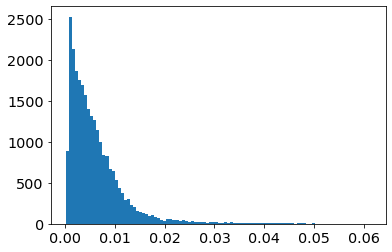

In [15]:
def failure_rate(flux, efftime, a0, a1, a2):
    sn = flux * np.sqrt(efftime)
    return np.clip(np.exp(a0*sn+a1)+a2/flux, 0, 1)

# Use the coefficients from the LRG target selection paper
coeffs = [-0.05147332, 0.86560286, 0.01410814]

a0, a1, a2 = -1/coeffs[1], -coeffs[0]/coeffs[1], coeffs[2]
print(a0, a1, a2)

cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']
cat['FIBERFLUX_Z_EC'] = cat['FIBERFLUX_Z']*10**(0.4*1.211*cat['EBV'])
cat['fail_prob'] = failure_rate(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *coeffs)

plt.hist(cat['fail_prob'], 100)
plt.show()

cat['spec_weight'] /= (1-cat['fail_prob'])

In [16]:
# Renormalize the spectro weights to the total density
# so it puts the "full" sample on the same weight scale as the binned subsamples
mask = mask_north.copy()
renorm_factor = densities['all_north'] / np.sum(cat['spec_weight'][mask])
cat['spec_weight'][mask] = cat['spec_weight'][mask] * renorm_factor
print('north', np.sum(cat['spec_weight'][mask]))

mask = mask_south.copy()
renorm_factor = densities['all_south'] / np.sum(cat['spec_weight'][mask])
cat['spec_weight'][mask] = cat['spec_weight'][mask] * renorm_factor
print('South', np.sum(cat['spec_weight'][mask]))

north 1695.4303242947576
South 1673.9602164197267


In [17]:
# Combine spectroscopic and imaging weights
cat['weight'] = cat['spec_weight'] * cat['imaging_weight']

In [18]:
# Renormalize the weights to the total density (targets per sq. deg.)
for field in ['north', 'south']:
    if field=='north':
        mask_field = mask_north.copy()
    elif field=='south':
        mask_field = mask_south.copy()
    else:
        raise ValueError()
    for pz_bin in range(1, 5):
        mask = mask_field & (cat['pz_bin']==pz_bin)
        renorm_factor = densities['bin_{}_{}'.format(pz_bin, field)] / np.sum(cat['weight'][mask])
        cat['weight'][mask] = cat['weight'][mask] * renorm_factor
        print('{}_{}'.format(field, pz_bin), np.sum(cat['weight'][mask]))

north_1 186.28787764421088
north_2 309.00465150018033
north_3 435.8116996466394
north_4 456.0017321950825
south_1 185.4461761724731
south_2 312.23760257188997
south_3 417.2338242804252
south_4 433.74461914935677


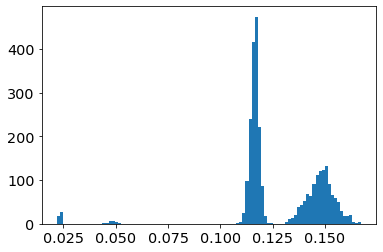

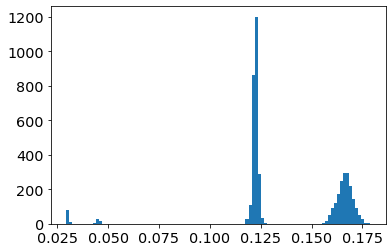

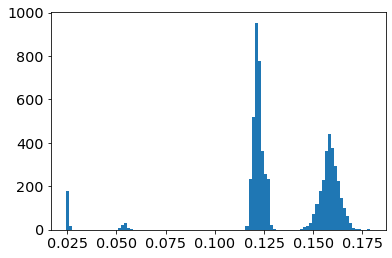

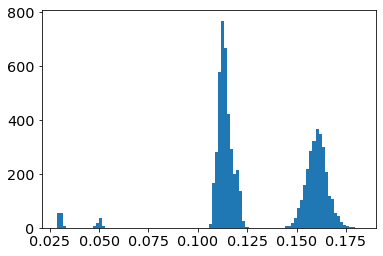

In [19]:
mask = cat['weight']!=0
mask &= cat['pz_bin']!=-1

for pz_bin in range(1, 5):
    mask1 = mask & (cat['pz_bin']==pz_bin)
    plt.hist(cat['weight'][mask1], 100)
    plt.show()

--------

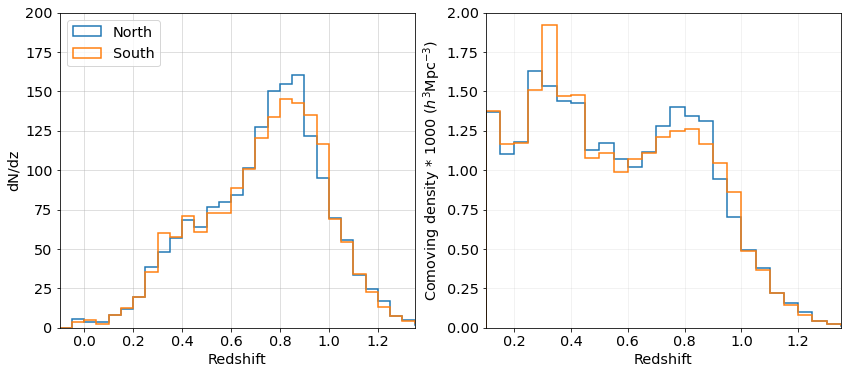

In [20]:
# No spectro weights

bins = np.arange(-0.1, 1.45, 0.05)
bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north], weights=np.full(np.sum(mask_north), np.mean(cat['spec_weight'][mask_north])),
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south], weights=np.full(np.sum(mask_south), np.mean(cat['spec_weight'][mask_south])),
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.35)
axes[0].set_ylim(0, 200)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 2], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 2], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

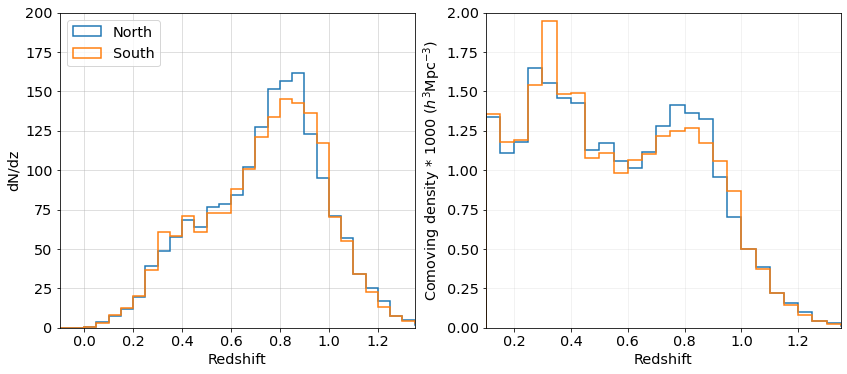

In [21]:
# With spectro weights

bins = np.arange(-0.1, 1.45, 0.05)
bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north], weights=cat['spec_weight'][mask_north],
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south], weights=cat['spec_weight'][mask_south],
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.35)
axes[0].set_ylim(0, 200)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, weights=cat['spec_weight'][mask_north]/np.mean(cat['spec_weight'][mask_north]), zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 2.], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, weights=cat['spec_weight'][mask_south]/np.mean(cat['spec_weight'][mask_south]), zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 2.], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

In [22]:
print('stellar fraction: {:.2f}%\n'.format(100*np.sum(mask_star)/len(mask_star)))

print('South:\n')
mask_all = mask_south & (cat['pz_bin']!=-1)
for pz_bin in range(1, 5):
    mask = mask_south & (cat['pz_bin']==pz_bin)
    print('bin {} fraction: {:.4f}'.format(pz_bin, np.sum(mask)/np.sum(mask_all)))
    # print(np.percentile(cat['Z'][mask], [2, 16, 50, 84, 98]))
    print('mean redshift: {:.3f}'.format(np.median(cat['Z'][mask])))
#     print('1-sigma width: {:.3f};   2-sigma width: {:.3f}'.format(np.percentile(cat['Z'][mask], 84)-np.percentile(cat['Z'][mask], 16),
#         np.percentile(cat['Z'][mask], 98)-np.percentile(cat['Z'][mask], 2)))
    print('nmad: {:.3f}'.format(nmad(cat['Z'][mask])))
    print('stellar fraction: {:.2f}%'.format(100*np.sum(mask_star & mask)/np.sum(mask)))
    print()

print()

print('North:\n')
mask_all = mask_north & (cat['pz_bin']!=-1)
for pz_bin in range(1, 5):
    mask = mask_north & (cat['pz_bin']==pz_bin)
    print('bin {} fraction: {:.4f}'.format(pz_bin, np.sum(mask)/np.sum(mask_all)))
    # print(np.percentile(cat['Z'][mask], [2, 16, 50, 84, 98]))
    print('mean redshift: {:.3f}'.format(np.median(cat['Z'][mask])))
#     print('1-sigma width: {:.3f};   2-sigma width: {:.3f}'.format(np.percentile(cat['Z'][mask], 84)-np.percentile(cat['Z'][mask], 16),
#         np.percentile(cat['Z'][mask], 98)-np.percentile(cat['Z'][mask], 2)))
    print('nmad: {:.3f}'.format(nmad(cat['Z'][mask])))
    print('stellar fraction: {:.2f}%'.format(100*np.sum(mask_star & mask)/np.sum(mask)))
    print()

stellar fraction: 0.51%

South:

bin 1 fraction: 0.1389
mean redshift: 0.469
nmad: 0.060
stellar fraction: 0.24%

bin 2 fraction: 0.2234
mean redshift: 0.632
nmad: 0.070
stellar fraction: 0.19%

bin 3 fraction: 0.3047
mean redshift: 0.790
nmad: 0.074
stellar fraction: 0.25%

bin 4 fraction: 0.3330
mean redshift: 0.928
nmad: 0.085
stellar fraction: 0.79%


North:

bin 1 fraction: 0.1435
mean redshift: 0.467
nmad: 0.062
stellar fraction: 0.31%

bin 2 fraction: 0.2137
mean redshift: 0.634
nmad: 0.075
stellar fraction: 0.26%

bin 3 fraction: 0.3148
mean redshift: 0.794
nmad: 0.077
stellar fraction: 0.18%

bin 4 fraction: 0.3280
mean redshift: 0.917
nmad: 0.099
stellar fraction: 0.93%



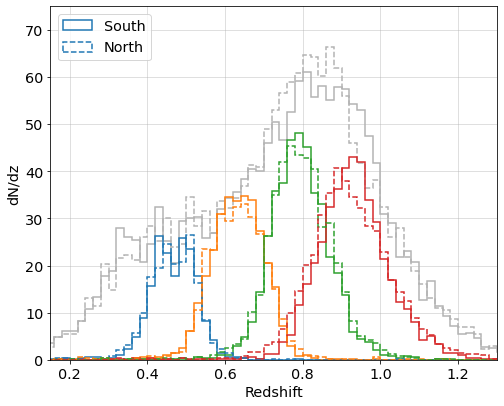

In [23]:
bins = np.arange(-0.1, 1.45, 0.02)
bin_centers = (bins[1:]+bins[:-1])/2

fig, ax = plt.subplots(figsize=(8, 6.5))

mask = mask_south.copy()
ax.hist(cat['Z'][mask], weights=cat['spec_weight'][mask],
             bins=bins, lw=1.5, histtype='step', color='0.7')
mask = mask_north.copy()
ax.hist(cat['Z'][mask], weights=cat['spec_weight'][mask],
             bins=bins, lw=1.5, histtype='step', color='0.7', ls='--')

for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'South'
    else:
        label = None
    mask = mask_south & (cat['pz_bin']==pz_bin)
    ax.hist(cat['Z'][mask], weights=cat['weight'][mask],
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(pz_bin-1))
for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'North'
    else:
        label = None
    mask = mask_north & (cat['pz_bin']==pz_bin)
    ax.hist(cat['Z'][mask], weights=cat['weight'][mask],
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(pz_bin-1), ls='--')

ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.15, 1.3)
ax.set_ylim(0, 75)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
plt.show()

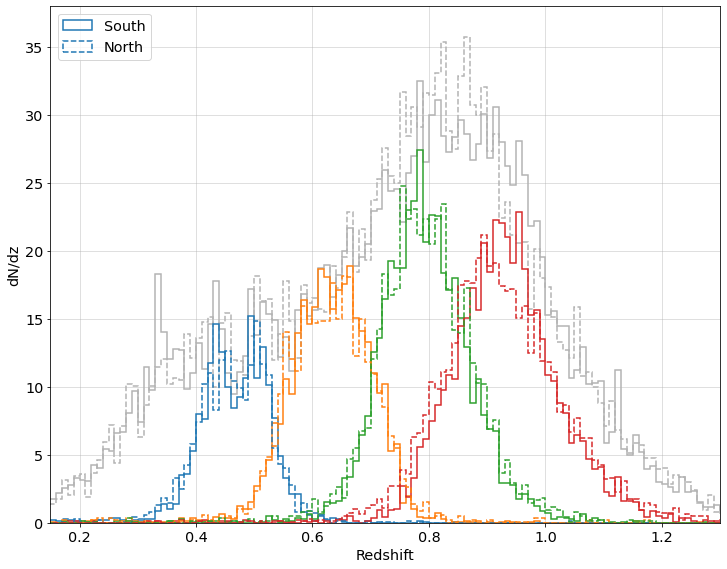

In [24]:
bins = np.arange(-0.1, 1.45, 0.01)
bin_centers = (bins[1:]+bins[:-1])/2

fig, ax = plt.subplots(figsize=(12, 9.5))

mask = mask_south.copy()
ax.hist(cat['Z'][mask], weights=cat['spec_weight'][mask],
             bins=bins, lw=1.5, histtype='step', color='0.7')
mask = mask_north.copy()
ax.hist(cat['Z'][mask], weights=cat['spec_weight'][mask],
             bins=bins, lw=1.5, histtype='step', color='0.7', ls='--')

for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'South'
    else:
        label = None
    mask = mask_south & (cat['pz_bin']==pz_bin)
    ax.hist(cat['Z'][mask], weights=cat['weight'][mask],
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(pz_bin-1))
for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'North'
    else:
        label = None
    mask = mask_north & (cat['pz_bin']==pz_bin)
    ax.hist(cat['Z'][mask], weights=cat['weight'][mask],
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(pz_bin-1), ls='--')

ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.15, 1.3)
ax.set_ylim(0, 38)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
plt.show()

In [25]:
bins = np.round(np.arange(0., 1.5, 0.02), 2)

t = Table()
t['zmin'] = bins[:-1]
t['zmax'] = bins[1:]

for pz_bin in range(0, 5):
    if pz_bin==0:
        mask = mask_north.copy()
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['spec_weight'][mask])[0]
        t['all_north'] = surf_density
        t['all_north'].format = '%.3f'
    else:
        mask = mask_north & (cat['pz_bin']==pz_bin)
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['weight'][mask])[0]
        t['bin_{}_north'.format(pz_bin)] = surf_density
        t['bin_{}_north'.format(pz_bin)].format = '%.3f'

for pz_bin in range(0, 5):
    if pz_bin==0:
        mask = mask_south.copy()
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['spec_weight'][mask])[0]
        t['all_south'] = surf_density
        t['all_south'].format = '%.3f'
    else:
        mask = mask_south & (cat['pz_bin']==pz_bin)
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['weight'][mask])[0]
        t['bin_{}_south'.format(pz_bin)] = surf_density
        t['bin_{}_south'.format(pz_bin)].format = '%.3f'
    
t.write('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/dndz/himalayas_v0.1/extended_lrg_pz_dndz_himalayas_v0.1_dz_0.02.txt', format='ascii.commented_header', overwrite=True)

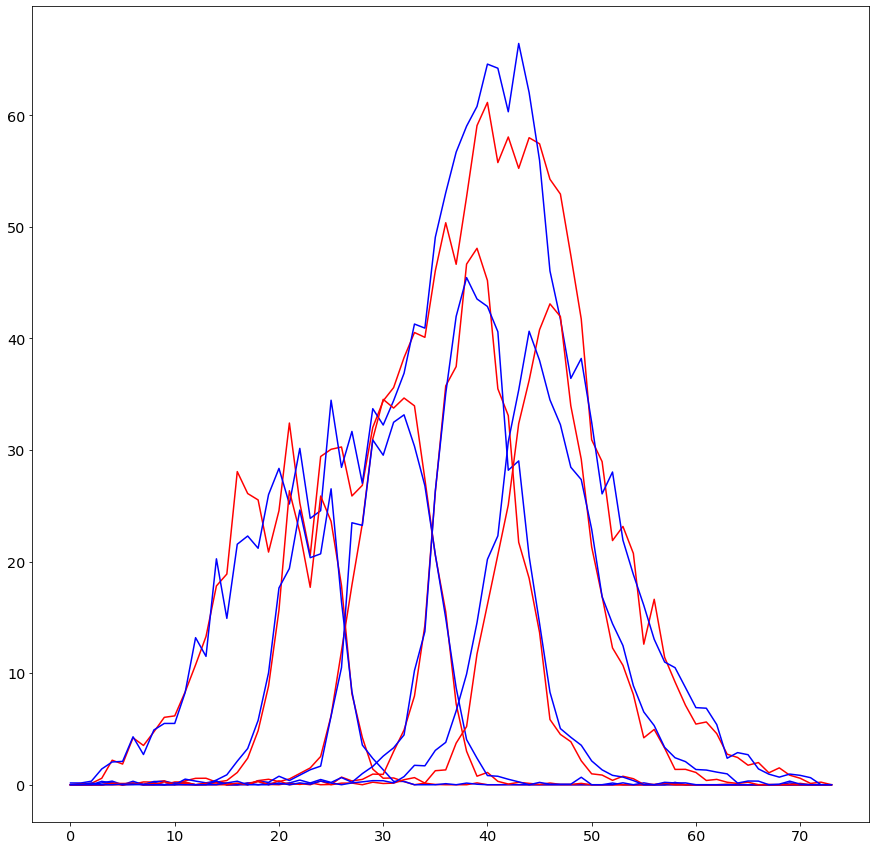

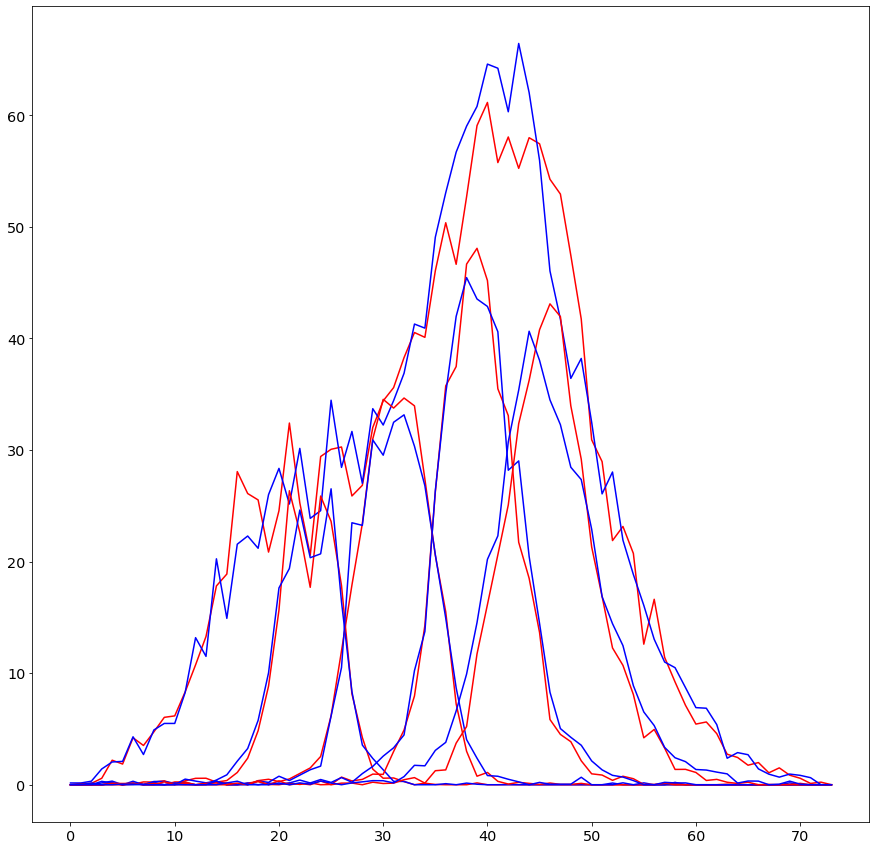

In [26]:
plt.figure(figsize=(15, 15))
plt.plot(t['all_south'], color='r')
plt.plot(t['all_north'], color='b')
for pz_bin in range(1, 5):
    plt.plot(t['bin_{}_south'.format(pz_bin)], color='r')
    plt.plot(t['bin_{}_north'.format(pz_bin)], color='b')
plt.show()

tt = Table.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/dndz/himalayas_v0.1/extended_lrg_pz_dndz_himalayas_v0.1_dz_0.02.txt', format='ascii.commented_header')
plt.figure(figsize=(15, 15))
plt.plot(tt['all_south'], color='r')
plt.plot(tt['all_north'], color='b')
for pz_bin in range(1, 5):
    plt.plot(tt['bin_{}_south'.format(pz_bin)], color='r')
    plt.plot(tt['bin_{}_north'.format(pz_bin)], color='b')
plt.show()

In [27]:
# bins = np.round(np.arange(0., 1.5, 0.01), 2)

# t = Table()
# t['zmin'] = bins[:-1]
# t['zmax'] = bins[1:]

# for pz_bin in range(0, 5):
#     if pz_bin==0:
#         mask = mask_north.copy()
#         mask &= (~mask_star)
#         surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['spec_weight'][mask])[0]
#         t['all_north'] = surf_density
#         t['all_north'].format = '%.3f'
#     else:
#         mask = mask_north & (cat['pz_bin']==pz_bin)
#         mask &= (~mask_star)
#         surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['weight'][mask])[0]
#         t['bin_{}_north'.format(pz_bin)] = surf_density
#         t['bin_{}_north'.format(pz_bin)].format = '%.3f'

# for pz_bin in range(0, 5):
#     if pz_bin==0:
#         mask = mask_south.copy()
#         mask &= (~mask_star)
#         surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['spec_weight'][mask])[0]
#         t['all_south'] = surf_density
#         t['all_south'].format = '%.3f'
#     else:
#         mask = mask_south & (cat['pz_bin']==pz_bin)
#         mask &= (~mask_star)
#         surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['weight'][mask])[0]
#         t['bin_{}_south'.format(pz_bin)] = surf_density
#         t['bin_{}_south'.format(pz_bin)].format = '%.3f'
    
# t.write('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/dndz/himalayas_v0.1/extended_lrg_pz_dndz_himalayas_v0.1_dz_0.01.txt', format='ascii.commented_header', overwrite=True)

# plt.figure(figsize=(15, 15))
# plt.plot(t['all_south'], color='r')
# plt.plot(t['all_north'], color='b')
# for pz_bin in range(1, 5):
#     plt.plot(t['bin_{}_south'.format(pz_bin)], color='r')
#     plt.plot(t['bin_{}_north'.format(pz_bin)], color='b')
# plt.show()

# tt = Table.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/dndz/himalayas_v0.1/extended_lrg_pz_dndz_himalayas_v0.1_dz_0.01.txt', format='ascii.commented_header')
# plt.figure(figsize=(15, 15))
# plt.plot(tt['all_south'], color='r')
# plt.plot(tt['all_north'], color='b')
# for pz_bin in range(1, 5):
#     plt.plot(tt['bin_{}_south'.format(pz_bin)], color='r')
#     plt.plot(tt['bin_{}_north'.format(pz_bin)], color='b')
# plt.show()